# 03 · Human-in-the-Loop Release Policy Simulation

            Convert model probabilities into an operational **ALLOW / REVIEW / BLOCK** policy while making the error costs explicit.

## tl;dr

            Under the declared synthetic cost model, the lowest-cost grid point sends scores below **0.10** to ALLOW, scores from **0.10–0.65** to REVIEW, and scores at or above **0.65** to BLOCK. On 120 test releases this produces **25 allow**, **39 review**, and **56 block** decisions at a total simulated cost of **23.55**.

## Context & Methods

            A single 0.5 classifier threshold hides operational trade-offs. This notebook searches two thresholds and prices three burdens:

            - Missed compromise released as ALLOW: **10 cost units**
            - Benign release incorrectly BLOCKed: **2 cost units**
            - Any manual REVIEW: **0.45 cost units**

            ### Key Assumptions

            The costs are illustrative, the test data is synthetic, and critical deterministic evidence still overrides the learned thresholds.

## Data

Reuse the same fixed split and feature contract as the model notebook.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or a child directory")
sys.path.insert(0, str(ROOT / "src"))

ORANGE = "#f97316"
GOLD = "#f59e0b"
BLUE = "#2563eb"
INK = "#172033"
GRID = "#e5e7eb"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

In [2]:
FEATURES = ['critical_count', 'high_count', 'medium_count', 'low_count', 'provenance_failures', 'workflow_exposures', 'vulnerable_components', 'blast_ratio']
frame = pd.read_csv(ROOT / 'data' / 'synthetic_scans.csv')
frame.groupby(['split', 'compromised']).size().unstack(fill_value=0)

compromised,0,1
split,,
test,50,70
train,160,200


## Results

Train once, score the held-out set once, and search policy thresholds without retraining.

In [3]:
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier

train = frame[frame["split"] == "train"].copy()
test = frame[frame["split"] == "test"].copy()
classifier = RandomForestClassifier(
    n_estimators=260, max_depth=6, min_samples_leaf=3,
    class_weight="balanced", random_state=42,
)
classifier.fit(train[FEATURES], train["compromised"])
probability = classifier.predict_proba(test[FEATURES])[:, 1]
labels = test["compromised"].to_numpy()

rows = []
for review_threshold in np.arange(0.10, 0.61, 0.05):
    for block_threshold in np.arange(review_threshold + 0.10, 0.96, 0.05):
        decision = np.where(
            probability >= block_threshold, "BLOCK",
            np.where(probability >= review_threshold, "REVIEW", "ALLOW"),
        )
        false_allow = int(((labels == 1) & (decision == "ALLOW")).sum())
        false_block = int(((labels == 0) & (decision == "BLOCK")).sum())
        review_count = int((decision == "REVIEW").sum())
        rows.append({
            "review_threshold": round(float(review_threshold), 2),
            "block_threshold": round(float(block_threshold), 2),
            "false_allow": false_allow,
            "false_block": false_block,
            "review_count": review_count,
            "cost": 10 * false_allow + 2 * false_block + 0.45 * review_count,
        })

grid = pd.DataFrame(rows)
best = grid.sort_values(["cost", "false_allow", "review_count"]).iloc[0]
best.to_frame("value")

,value
review_threshold,0.10
block_threshold,0.65
false_allow,0.00
false_block,3.00
review_count,39.00
cost,23.55


<notebook>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


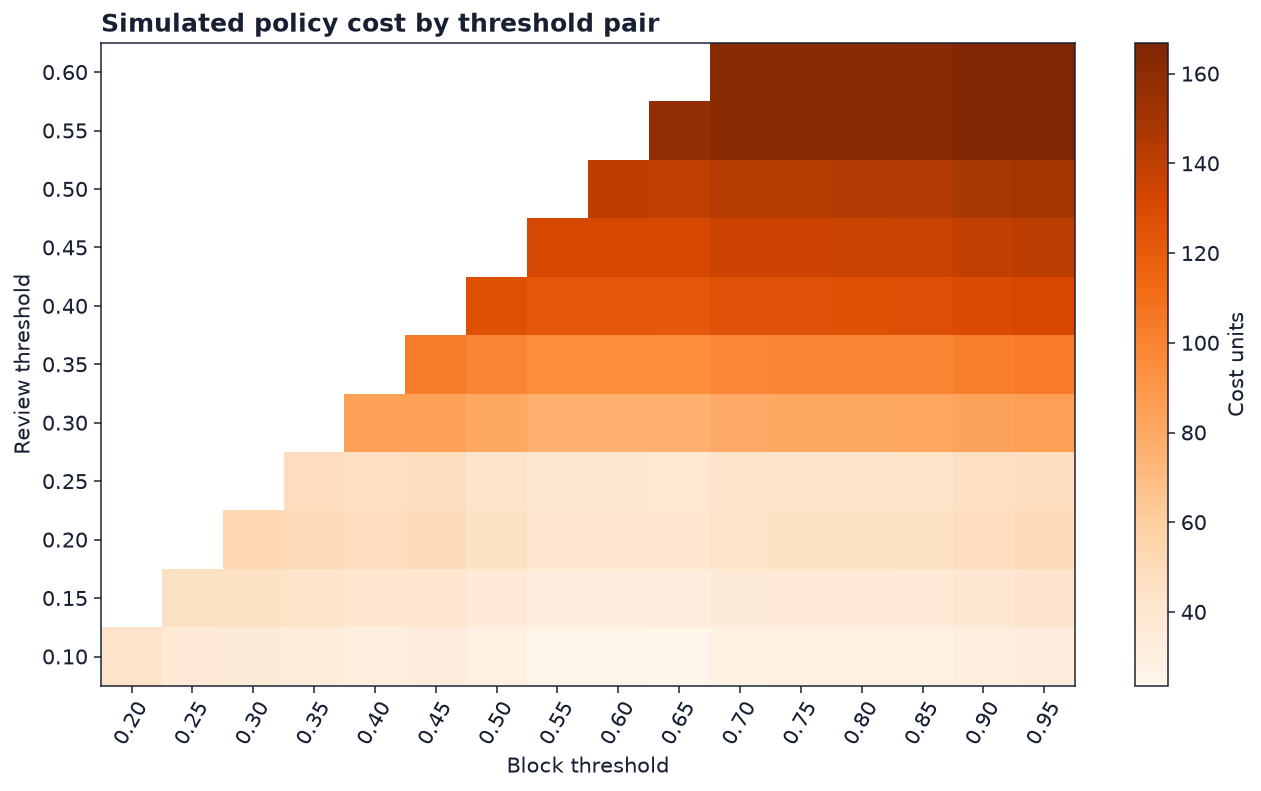

In [4]:
pivot = grid.pivot(index="review_threshold", columns="block_threshold", values="cost")
fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(pivot, origin="lower", aspect="auto", cmap="Oranges")
ax.set_xticks(range(len(pivot.columns)), [f"{value:.2f}" for value in pivot.columns], rotation=60)
ax.set_yticks(range(len(pivot.index)), [f"{value:.2f}" for value in pivot.index])
ax.set_xlabel("Block threshold")
ax.set_ylabel("Review threshold")
ax.set_title("Simulated policy cost by threshold pair", loc="left", fontweight="bold")
fig.colorbar(image, ax=ax, label="Cost units")
plt.tight_layout()
plt.show()

<notebook>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


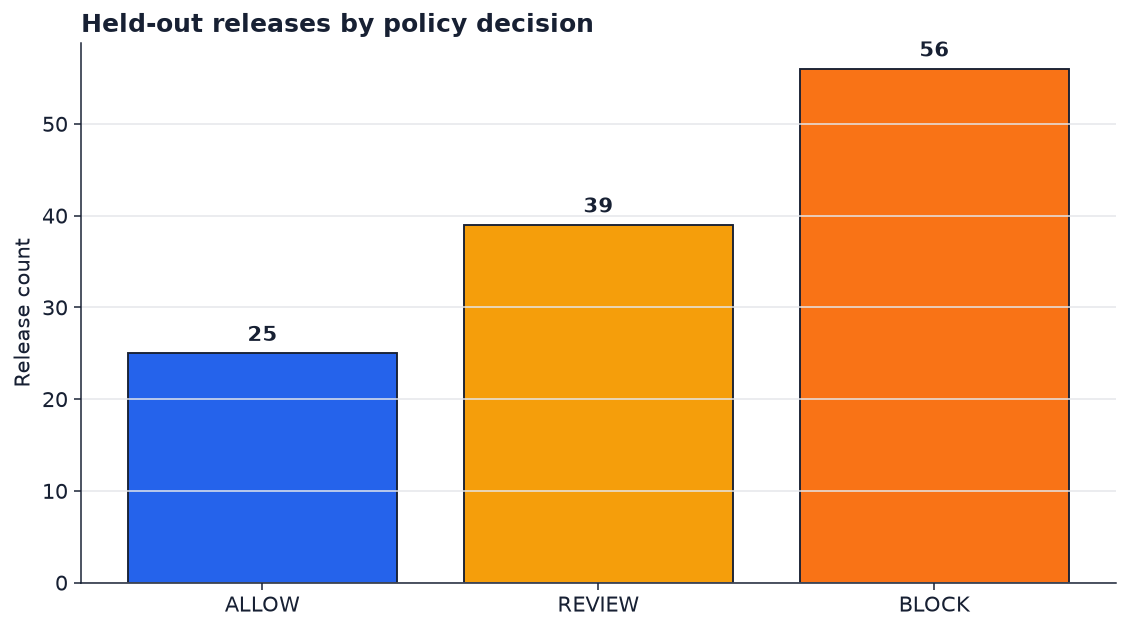

In [5]:
review_threshold = float(best["review_threshold"])
block_threshold = float(best["block_threshold"])
decision = np.where(
    probability >= block_threshold, "BLOCK",
    np.where(probability >= review_threshold, "REVIEW", "ALLOW"),
)
decision_counts = pd.Series(decision).value_counts().reindex(["ALLOW", "REVIEW", "BLOCK"], fill_value=0)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(decision_counts.index, decision_counts.values, color=[BLUE, GOLD, ORANGE], edgecolor=INK)
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Held-out releases by policy decision", loc="left", fontweight="bold")
ax.set_ylabel("Release count")
ax.grid(axis="y", color=GRID)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

<notebook>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


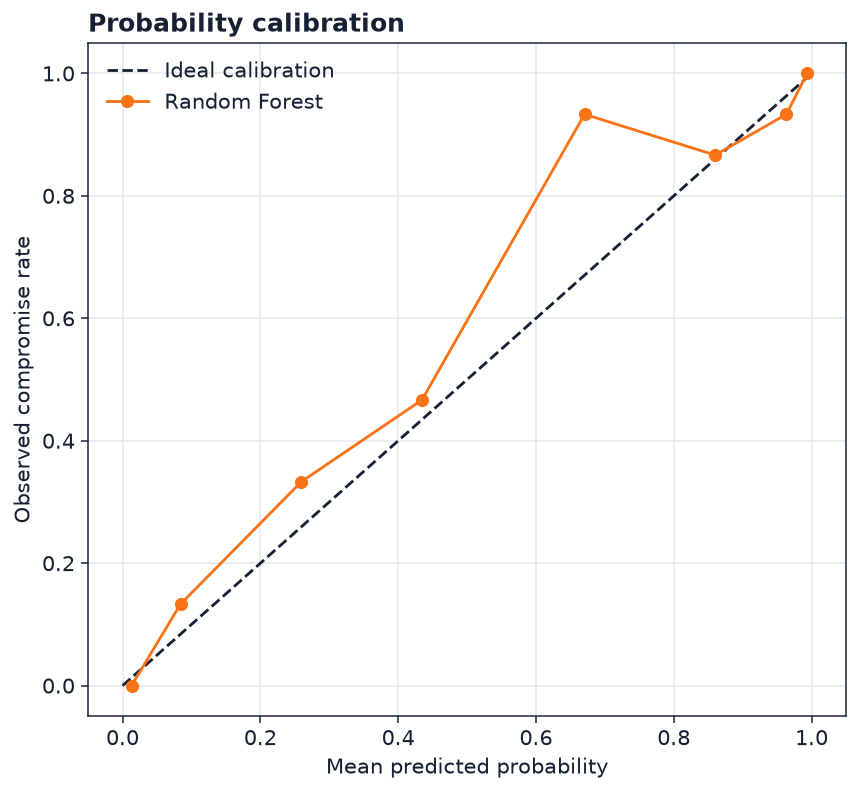

In [6]:
observed, predicted = calibration_curve(labels, probability, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color=INK, label="Ideal calibration")
ax.plot(predicted, observed, marker="o", color=ORANGE, label="Random Forest")
ax.set_title("Probability calibration", loc="left", fontweight="bold")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed compromise rate")
ax.grid(color=GRID)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Takeaways

            1. A review band preserves human judgment for ambiguous scores instead of pretending every probability is a binary fact.
            2. The illustrative optimum is **review ≥ 0.10** and **block ≥ 0.65**, but production costs must come from security and release owners.
            3. Digest mismatch, unsigned provenance, and equivalent hard controls should remain policy overrides even when the model is uncertain.